In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the Dataset

In [2]:
df = pd.read_csv("dataset.csv")

# Data Cleaning

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1902386530,C1286084959
freq,2237500,3,113


In [7]:
df.isnull().sum().sum()

0

In [8]:
df.duplicated().sum()

0

# EDA

In [9]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3934210,285,CASH_IN,141806.27,C255639026,800377.00,942183.27,C1965035271,0.00,0.00,0,0
4093090,301,PAYMENT,15576.44,C489122626,0.00,0.00,M1618310356,0.00,0.00,0,0
3214860,249,PAYMENT,12407.04,C2031804563,1048.00,0.00,M1104918650,0.00,0.00,0,0
4805630,346,CASH_OUT,69155.99,C1549824787,0.00,0.00,C61288357,1751869.50,1821025.49,0,0
2267049,187,PAYMENT,2398.31,C1872321935,37129.48,34731.17,M359715672,0.00,0.00,0,0
1208348,133,CASH_IN,237584.24,C1117942226,9081.00,246665.24,C1535126818,185691.12,0.00,0,0
5237165,371,PAYMENT,33284.98,C145947741,0.00,0.00,M2134660709,0.00,0.00,0,0
4921393,350,CASH_OUT,113301.03,C762868316,0.00,0.00,C1775893376,1176567.35,1289868.38,0,0
6281722,649,CASH_IN,563745.96,C1761128612,3790309.92,4354055.89,C1056815878,586546.66,22800.69,0,0
6088176,522,CASH_OUT,274685.47,C483221869,0.00,0.00,C1395650784,417644.75,692330.22,0,0


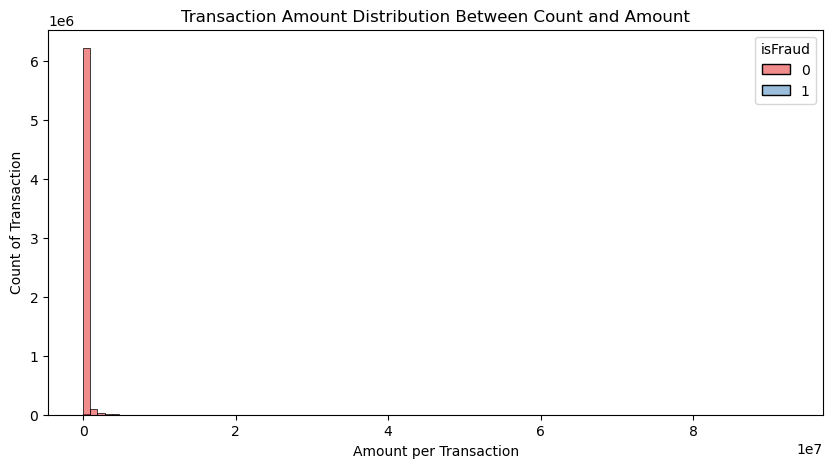

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='amount', hue='isFraud', bins=100, kde=False, palette='Set1')
plt.title("Transaction Amount Distribution Between Count and Amount")
plt.xlabel("Amount per Transaction")
plt.ylabel("Count of Transaction")
plt.show()

> *From the above plot we can see, the fraud has was way less counts than normal transaction*

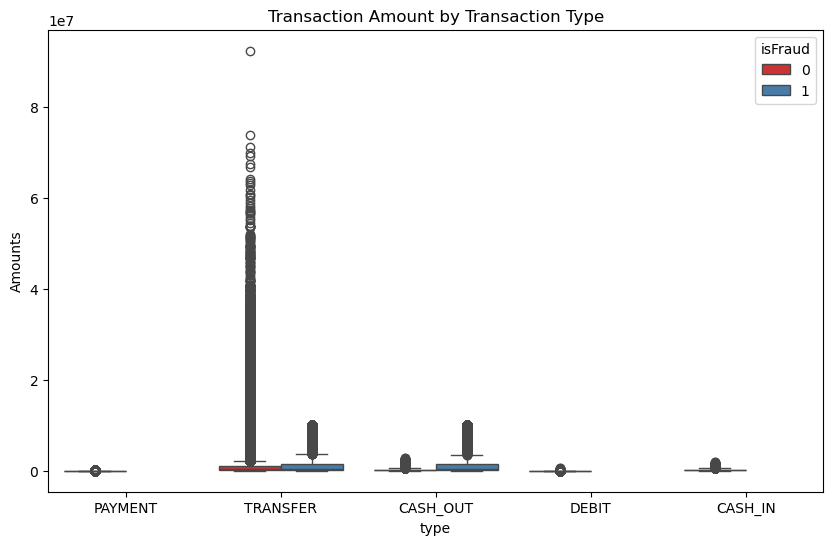

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='amount', hue='isFraud', palette='Set1')
plt.title("Transaction Amount by Transaction Type")
plt.ylabel("Amounts")
plt.show()

 > #### *The above boxplot represents Transaction amount by different transaction type. So in the plot we can see the only Transfer and Cash out has fraud count. Also Cash_out has way more fraud than normal transaction.*

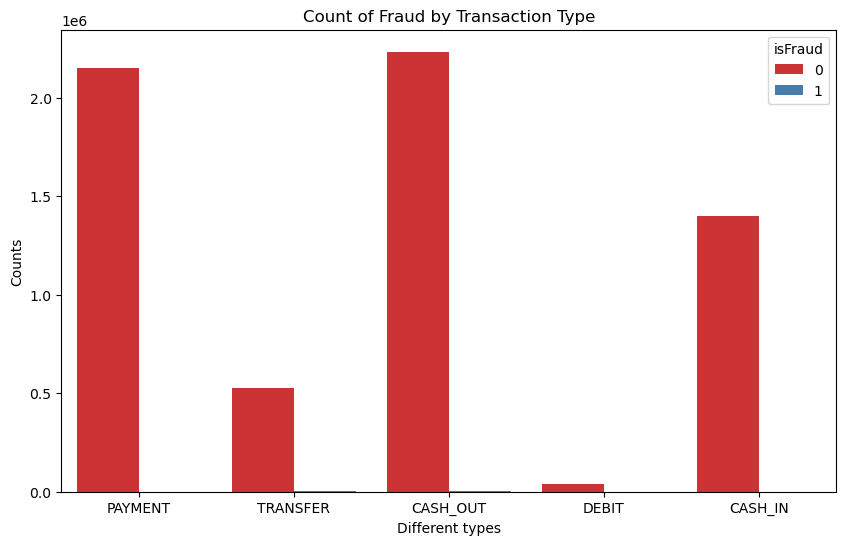

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='type', hue='isFraud', palette='Set1')
plt.title("Count of Fraud by Transaction Type")
plt.xlabel("Different types")
plt.ylabel("Counts")
plt.show()

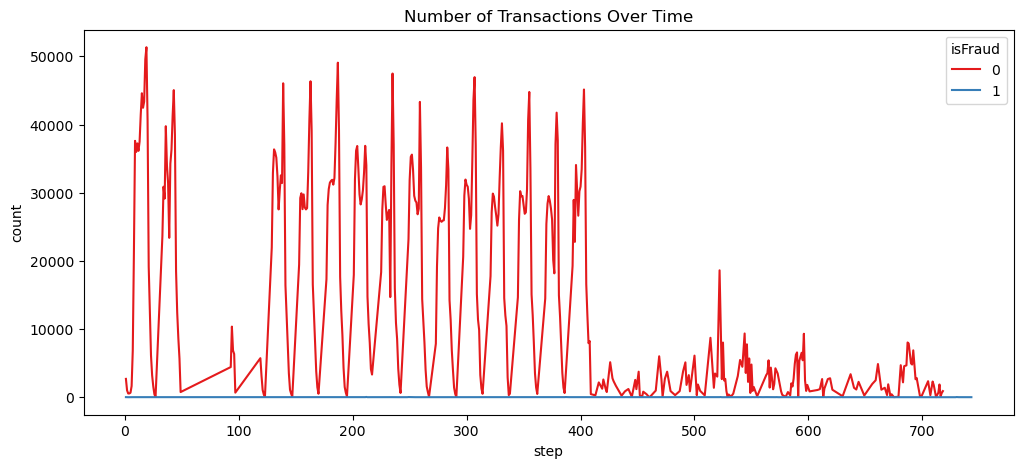

In [14]:
time_counts = df.groupby(['step', 'isFraud']).size().reset_index(name='count')
plt.figure(figsize=(12,5))
sns.lineplot(data=time_counts, x='step', y='count', hue='isFraud', palette='Set1')
plt.title("Number of Transactions Over Time")
plt.show()

C:\Users\Deadpool\AppData\Local\Temp\ipykernel_2988\3902002672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud', y='amount', palette='Set1')


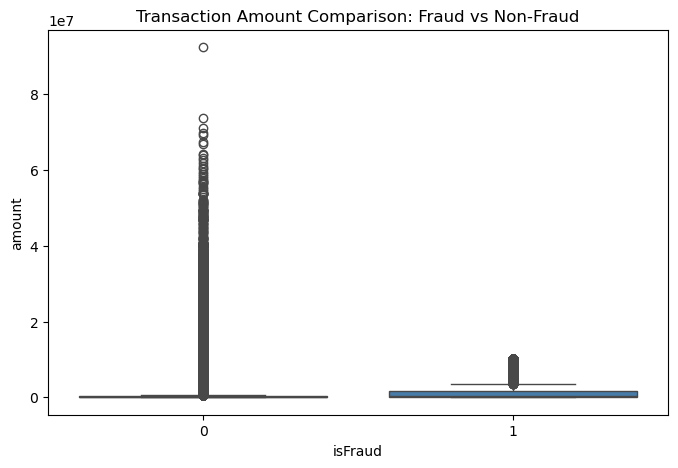

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='amount', palette='Set1')
plt.title("Transaction Amount Comparison: Fraud vs Non-Fraud")
plt.show()

C:\Users\Deadpool\AppData\Local\Temp\ipykernel_2988\3988624719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_senders, x='nameOrig', y='amount', palette='Set2')


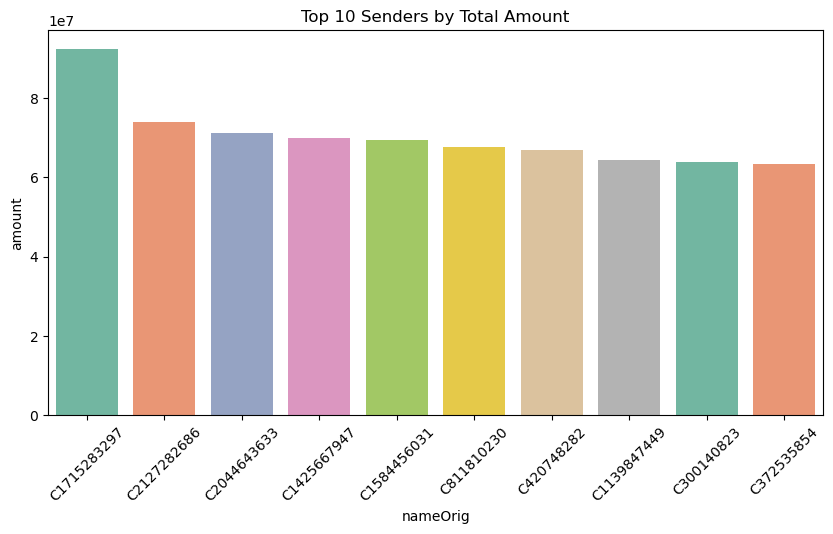

In [16]:
top_senders = df.groupby('nameOrig')['amount'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=top_senders, x='nameOrig', y='amount', palette='Set2')
plt.title("Top 10 Senders by Total Amount")
plt.xticks(rotation=45)
plt.show()

C:\Users\Deadpool\AppData\Local\Temp\ipykernel_2988\1038346815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_receivers, x='nameDest', y='amount', palette='Set2')


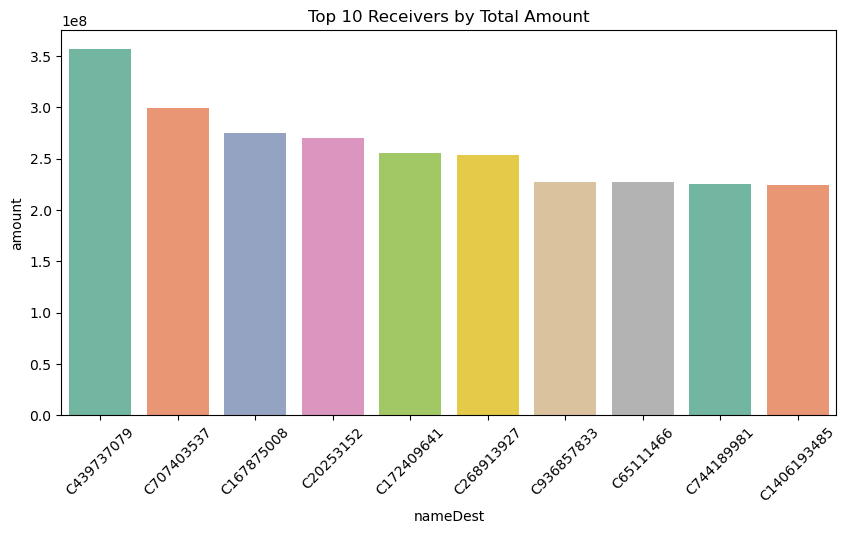

In [17]:
top_receivers = df.groupby('nameDest')['amount'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=top_receivers, x='nameDest', y='amount', palette='Set2')
plt.title("Top 10 Receivers by Total Amount")
plt.xticks(rotation=45)
plt.show()

> ### **Another interesting insight we can note down from the above two plots that the Sender send 2x amount than the receiver receive. so we can sender is 2x and receivers is x.**

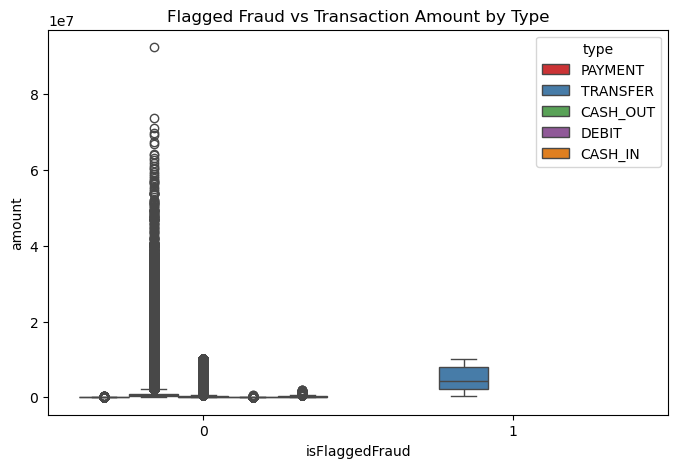

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFlaggedFraud', y='amount', hue='type', palette='Set1')
plt.title("Flagged Fraud vs Transaction Amount by Type")
plt.show()

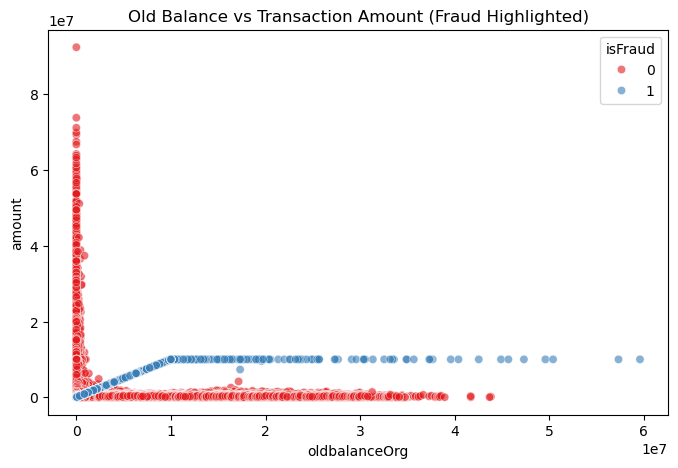

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='oldbalanceOrg', y='amount', hue='isFraud', palette='Set1', alpha=0.6)
plt.title("Old Balance vs Transaction Amount (Fraud Highlighted)")
plt.show()

# Feature Engineering and Model Training

In [20]:
df.drop(columns=["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"])

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0
...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,C776919290,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,C1881841831,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,C1365125890,1,0
6362618,743,TRANSFER,850002.52,C1685995037,C2080388513,1,0
